In [1]:
import yfinance as yf
import os
import pandas as pd

# Check if VIX data file exists
if not os.path.exists('vix_data.csv'):
    # Download VIX data from Yahoo Finance if file doesn't exist
    vix = yf.download('^VIX', start='2001-01-01', end='2024-12-31')
    # Save to CSV
    vix.to_csv('vix_data.csv')
else:
    # Load existing VIX data if file exists
    vix = pd.read_csv('vix_data.csv')


## Data Loading and Preprocessing

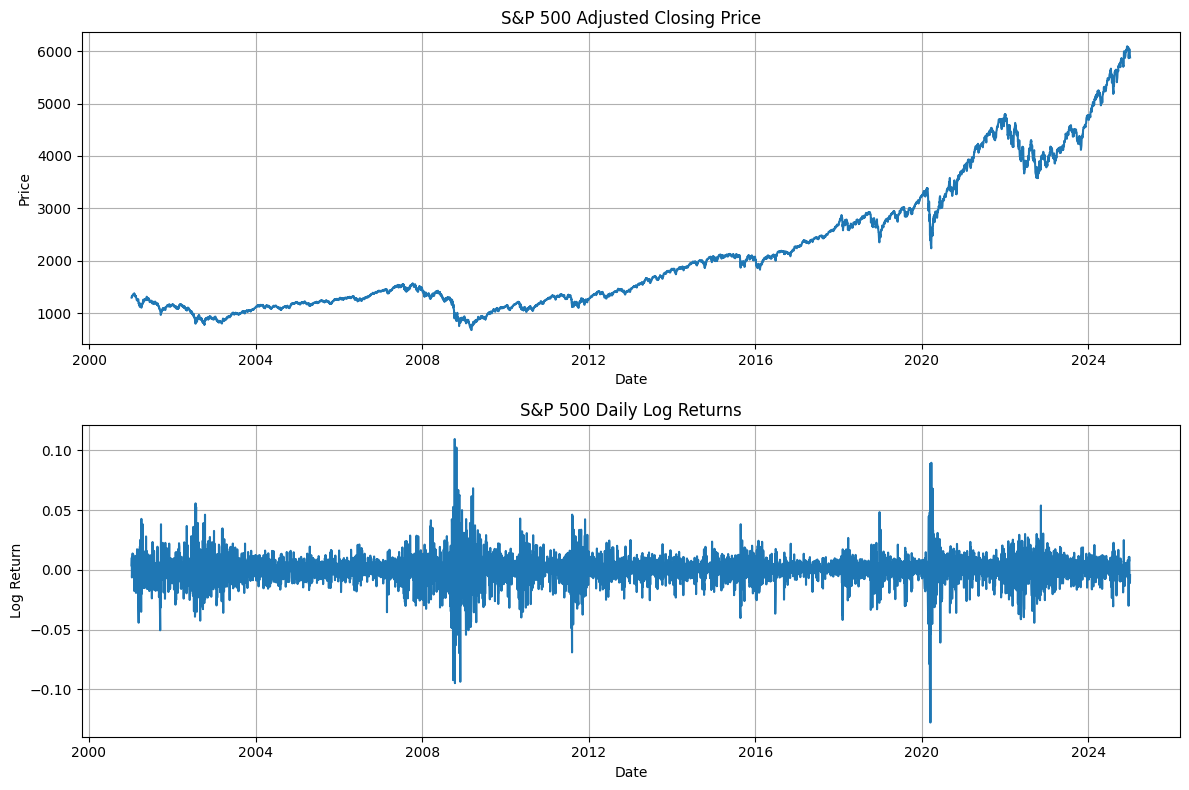

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load SPX data
# Check if SPX data file exists
if not os.path.exists('spx_data.csv'):
    # Download SPX data from Yahoo Finance if file doesn't exist
    spx = yf.download('^GSPC', start='2001-01-01', end='2024-12-31')
    # Save to CSV
    spx.to_csv('spx_data.csv')
else:
    # Load existing SPX data if file exists
    spx = pd.read_csv('spx_data.csv')

spx['Date'] = pd.to_datetime(spx['Date'])
spx = spx.set_index('Date')

# Calculate log returns
spx['LogReturn'] = np.log(spx['Adj Close']/spx['Adj Close'].shift(1))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot adjusted closing price
ax1.plot(spx.index.to_numpy(), spx['Adj Close'].to_numpy())
ax1.set_title('S&P 500 Adjusted Closing Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.grid(True)

# Plot log returns
ax2.plot(spx.index.to_numpy(), spx['LogReturn'].to_numpy())
ax2.set_title('S&P 500 Daily Log Returns')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.grid(True)
plt.tight_layout()
plt.savefig('spx_log_return_series.pdf')
plt.show()


## Weekly, Monthly, Quarterly Log Returns

In [3]:
# Calculate weekly (5-day) log returns
spx['WeeklyLogReturn'] = np.log(spx['Adj Close']/spx['Adj Close'].shift(5))

# Calculate monthly (21-day) log returns 
spx['MonthlyLogReturn'] = np.log(spx['Adj Close']/spx['Adj Close'].shift(21))

# Calculate quarterly (63-day) log returns
spx['QuarterlyLogReturn'] = np.log(spx['Adj Close']/spx['Adj Close'].shift(63))


## Styled Facts of Financial Returns

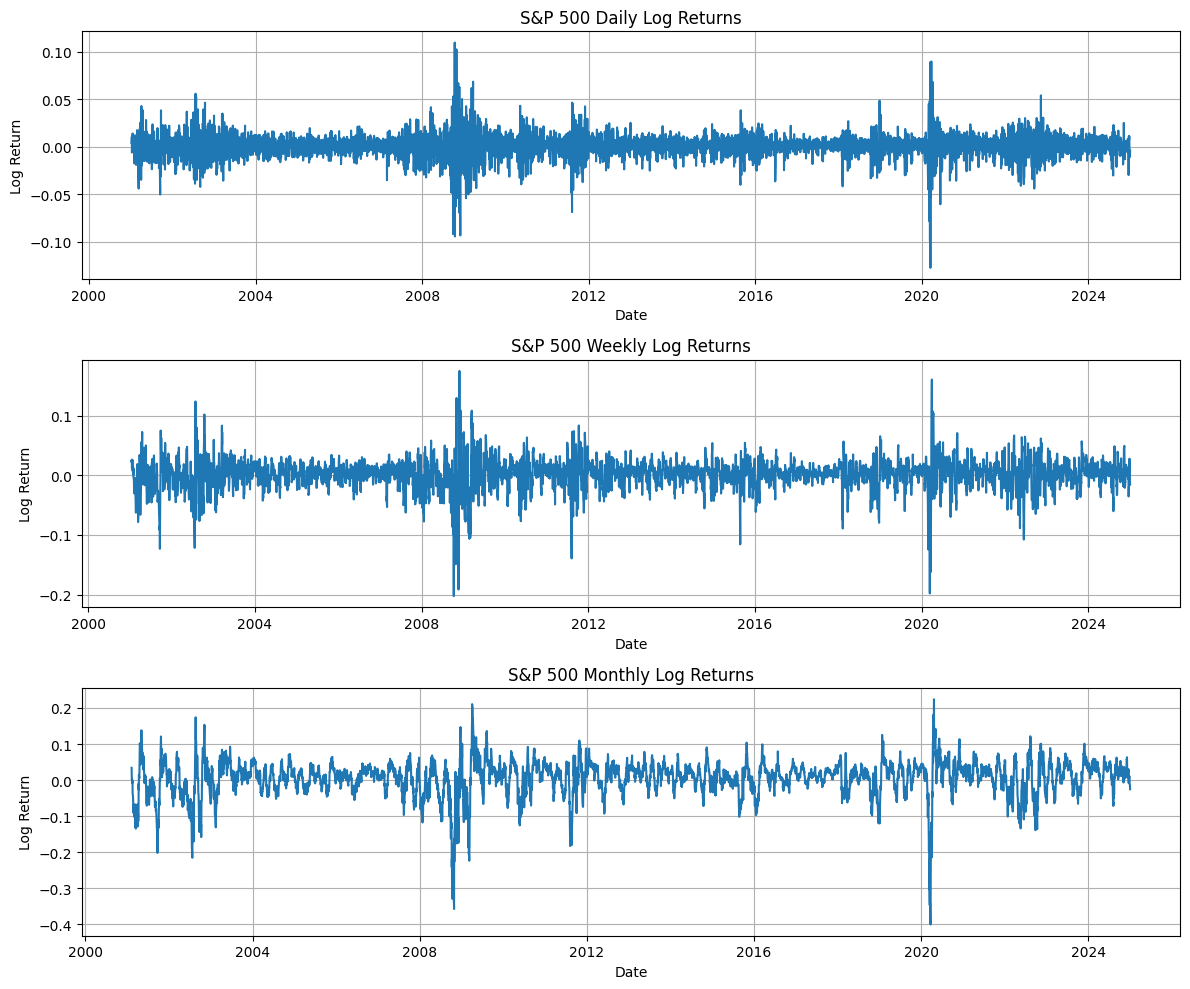

In [4]:
# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Plot daily log returns
ax1.plot(spx.index.to_numpy(), spx['LogReturn'].to_numpy())
ax1.set_title('S&P 500 Daily Log Returns')
ax1.set_xlabel('Date')
ax1.set_ylabel('Log Return')
ax1.grid(True)

# Plot weekly log returns
ax2.plot(spx.index.to_numpy(), spx['WeeklyLogReturn'].to_numpy())
ax2.set_title('S&P 500 Weekly Log Returns')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.grid(True)

# Plot monthly log returns
ax3.plot(spx.index.to_numpy(), spx['MonthlyLogReturn'].to_numpy())
ax3.set_title('S&P 500 Monthly Log Returns')
ax3.set_xlabel('Date')
ax3.set_ylabel('Log Return')
ax3.grid(True)

plt.tight_layout()
plt.savefig('spx_multi_period_returns.pdf')
plt.show()


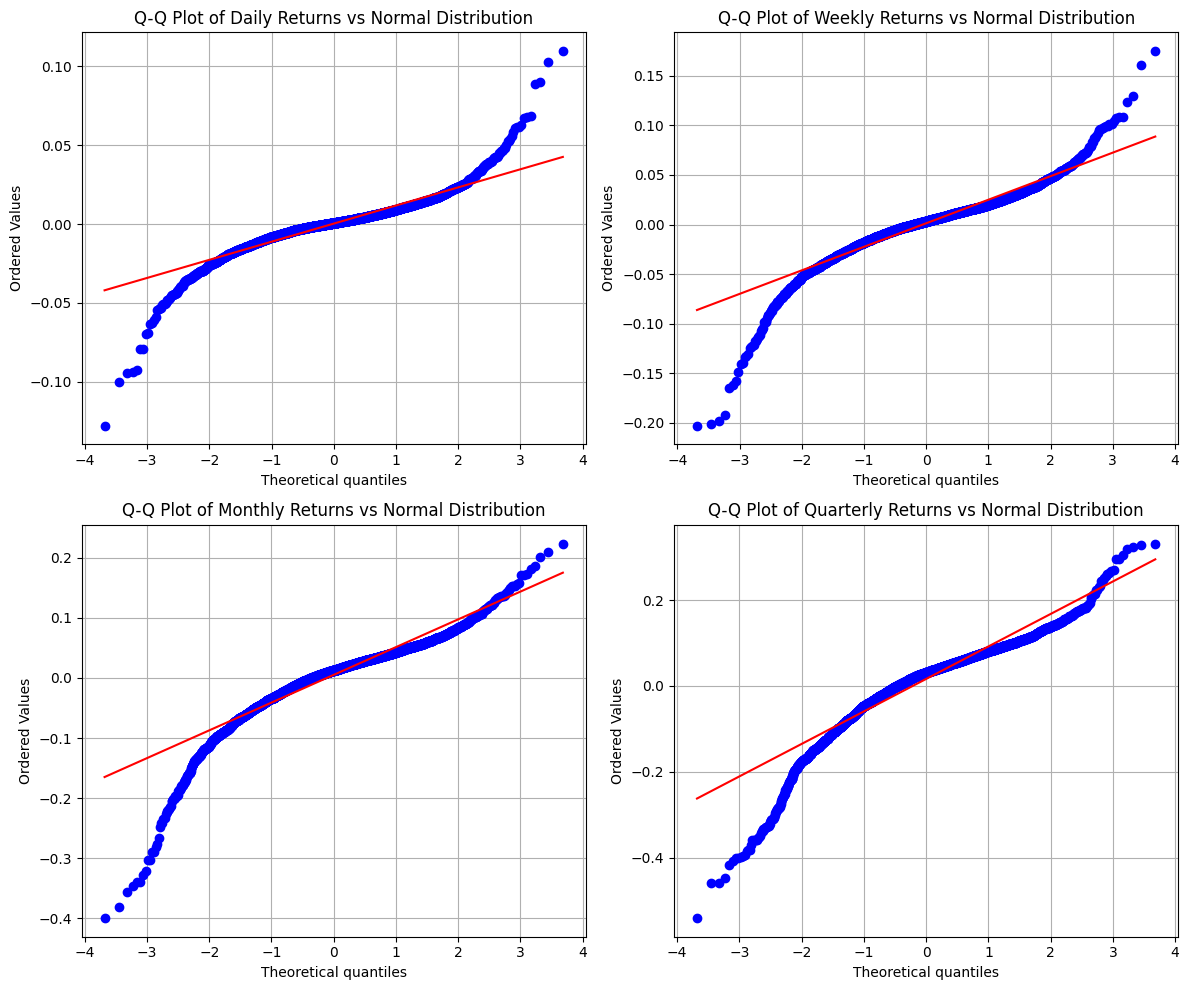

In [5]:
# Create figure with three subplots for QQ plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# QQ plot for daily returns
from scipy import stats
stats.probplot(spx['LogReturn'].dropna(), dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot of Daily Returns vs Normal Distribution')
ax1.grid(True)

# QQ plot for weekly returns 
stats.probplot(spx['WeeklyLogReturn'].dropna(), dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot of Weekly Returns vs Normal Distribution')
ax2.grid(True)

# QQ plot for monthly returns
stats.probplot(spx['MonthlyLogReturn'].dropna(), dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot of Monthly Returns vs Normal Distribution')
ax3.grid(True)

# QQ plot for quarterly returns
stats.probplot(spx['QuarterlyLogReturn'].dropna(), dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot of Quarterly Returns vs Normal Distribution')
ax4.grid(True)

plt.tight_layout()
plt.savefig('spx_returns_qq_plots.pdf')
plt.show()


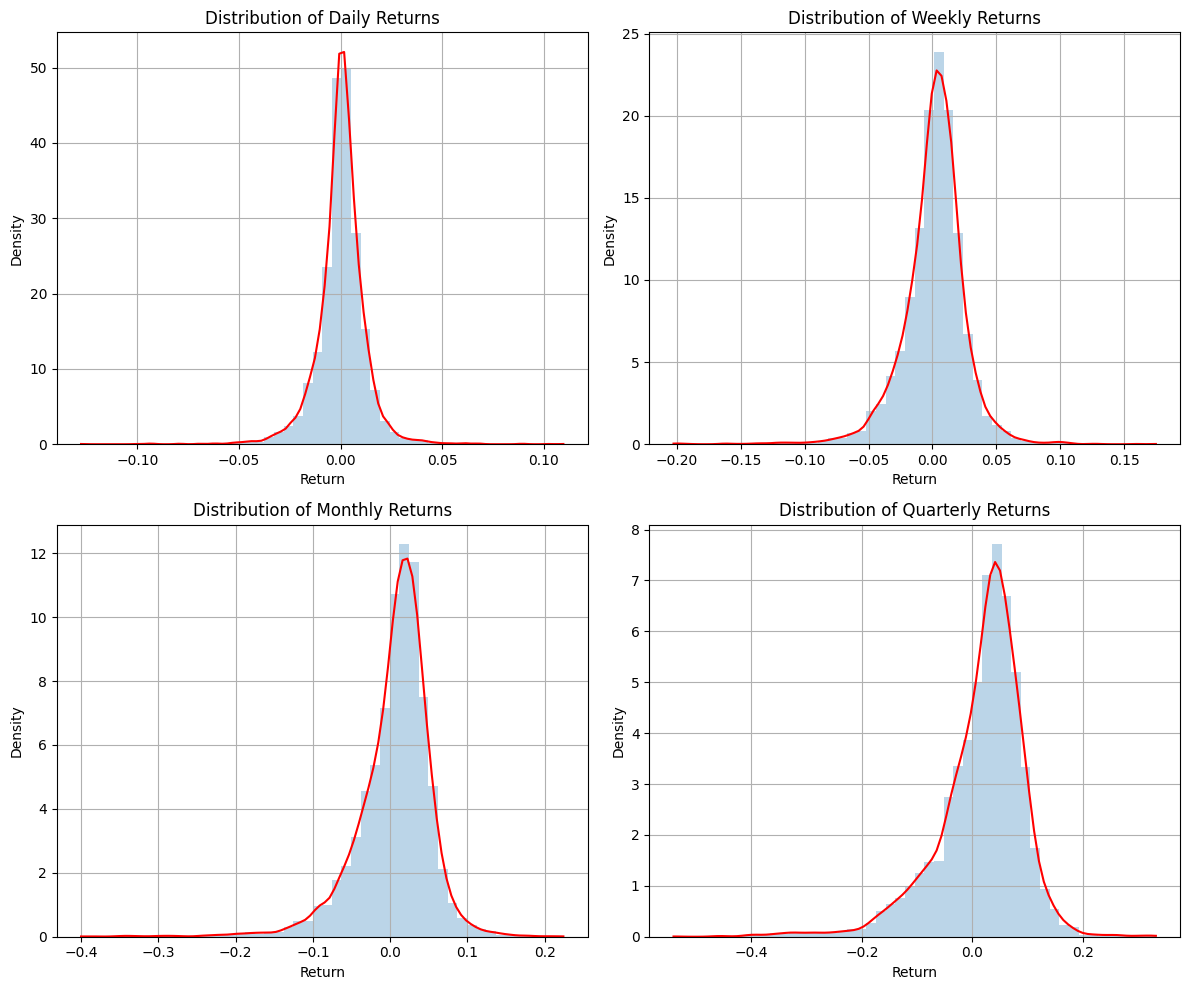

In [6]:
import matplotlib.pyplot as plt

# Create figure with 2x2 subplots for histograms
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Plot histogram and KDE for daily returns
ax1.hist(spx['LogReturn'].dropna().values, bins=50, density=True, alpha=0.3)
daily_returns = spx['LogReturn'].dropna().values
kde_x = np.linspace(daily_returns.min(), daily_returns.max(), 100)
kde = stats.gaussian_kde(daily_returns)
ax1.plot(kde_x, kde(kde_x), 'r-')
ax1.set_title('Distribution of Daily Returns')
ax1.set_xlabel('Return')
ax1.set_ylabel('Density')
ax1.grid(True)

# Plot histogram and KDE for weekly returns
ax2.hist(spx['WeeklyLogReturn'].dropna().values, bins=50, density=True, alpha=0.3)
weekly_returns = spx['WeeklyLogReturn'].dropna().values
kde_x = np.linspace(weekly_returns.min(), weekly_returns.max(), 100)
kde = stats.gaussian_kde(weekly_returns)
ax2.plot(kde_x, kde(kde_x), 'r-')
ax2.set_title('Distribution of Weekly Returns')
ax2.set_xlabel('Return')
ax2.set_ylabel('Density')
ax2.grid(True)

# Plot histogram and KDE for monthly returns
ax3.hist(spx['MonthlyLogReturn'].dropna().values, bins=50, density=True, alpha=0.3)
monthly_returns = spx['MonthlyLogReturn'].dropna().values
kde_x = np.linspace(monthly_returns.min(), monthly_returns.max(), 100)
kde = stats.gaussian_kde(monthly_returns)
ax3.plot(kde_x, kde(kde_x), 'r-')
ax3.set_title('Distribution of Monthly Returns')
ax3.set_xlabel('Return')
ax3.set_ylabel('Density')
ax3.grid(True)

# Plot histogram and KDE for quarterly returns
ax4.hist(spx['QuarterlyLogReturn'].dropna().values, bins=50, density=True, alpha=0.3)
quarterly_returns = spx['QuarterlyLogReturn'].dropna().values
kde_x = np.linspace(quarterly_returns.min(), quarterly_returns.max(), 100)
kde = stats.gaussian_kde(quarterly_returns)
ax4.plot(kde_x, kde(kde_x), 'r-')
ax4.set_title('Distribution of Quarterly Returns')
ax4.set_xlabel('Return')
ax4.set_ylabel('Density')
ax4.grid(True)

plt.tight_layout()
plt.savefig('spx_returns_distributions.pdf')
plt.show()


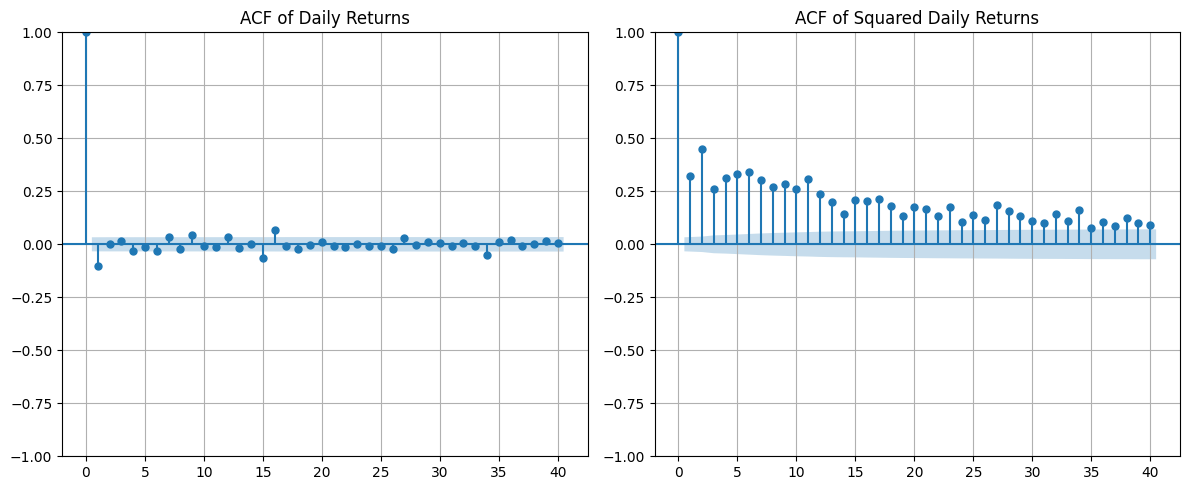

In [7]:
# Create figure with 1 row and 2 columns for ACF plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ACF plot for daily returns and squared daily returns
from statsmodels.graphics.tsaplots import plot_acf

# Daily returns
plot_acf(spx['LogReturn'].dropna(), lags=40, ax=ax1, title='ACF of Daily Returns', alpha=0.01)
ax1.grid(True)

# Squared daily returns
plot_acf(spx['LogReturn'].dropna()**2, lags=40, ax=ax2, title='ACF of Squared Daily Returns', alpha=0.01)
ax2.grid(True)

plt.tight_layout()
plt.savefig('spx_acf_plots.pdf')
plt.show()


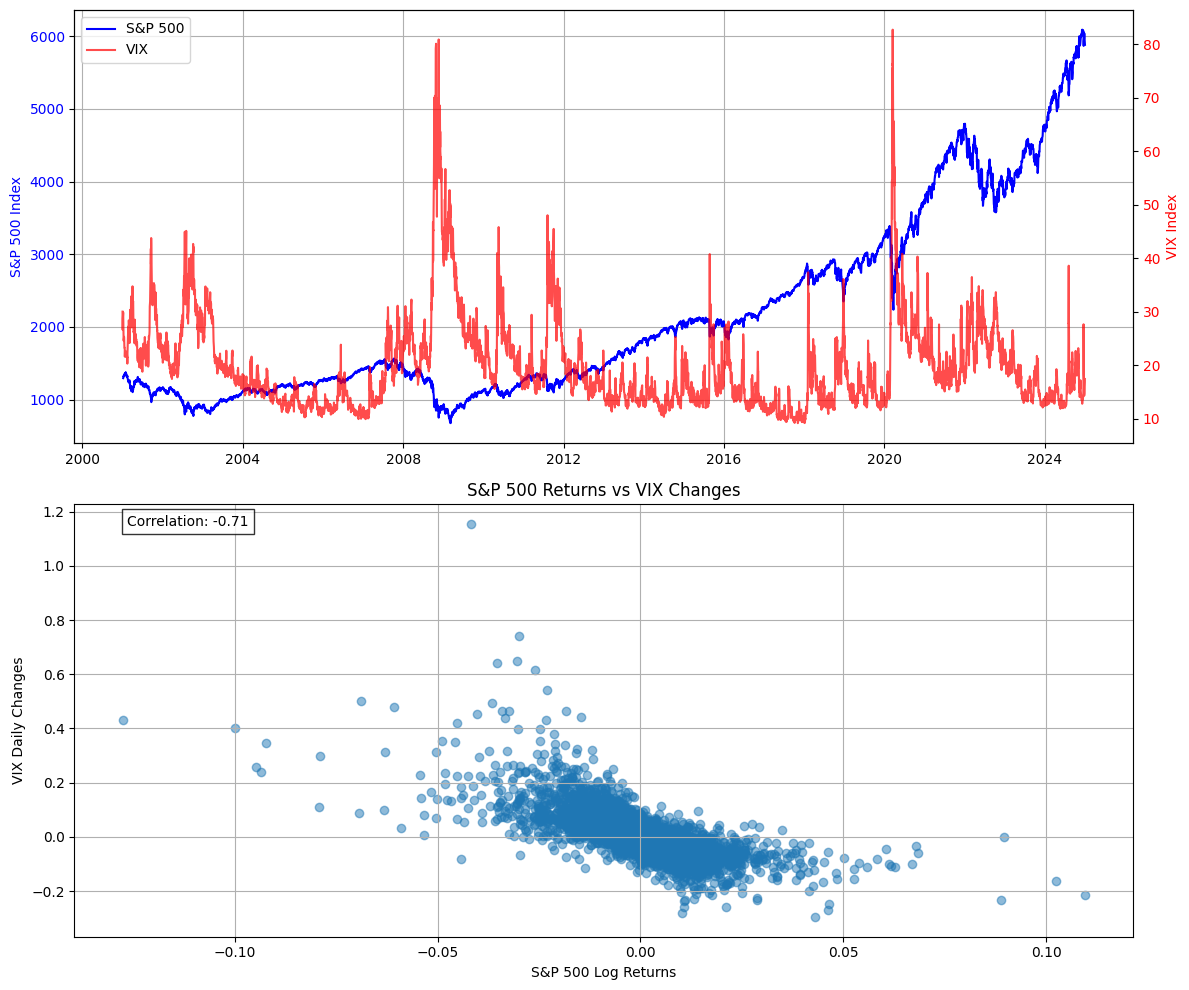

In [8]:
# Load VIX data
vix = pd.read_csv('vix_data.csv', index_col='Date', parse_dates=True)

# Create figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot SPX price and VIX on dual axes
ax1.plot(spx.index.to_numpy(), spx['Close'].to_numpy(), 'b-', label='S&P 500')
ax1.set_ylabel('S&P 500 Index', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True)

ax1_twin = ax1.twinx()
ax1_twin.plot(vix.index.to_numpy(), vix['Close'].to_numpy(), 'r-', label='VIX', alpha=0.7)
ax1_twin.set_ylabel('VIX Index', color='r')
ax1_twin.tick_params(axis='y', labelcolor='r')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Calculate VIX daily changes
vix['Change'] = vix['Close'].pct_change()

# Create scatter plot of VIX changes vs SPX returns
# Align dates between SPX and VIX data
common_dates = spx.index.intersection(vix.index)
spx_returns = spx.loc[common_dates, 'LogReturn']
vix_changes = vix.loc[common_dates, 'Change']

ax2.scatter(spx_returns, vix_changes, alpha=0.5)
ax2.set_xlabel('S&P 500 Log Returns')
ax2.set_ylabel('VIX Daily Changes')
ax2.grid(True)
ax2.set_title('S&P 500 Returns vs VIX Changes')

# Add correlation coefficient to the plot
corr = spx['LogReturn'].corr(vix['Change'])
ax2.text(0.05, 0.95, f'Correlation: {corr:.2f}', 
         transform=ax2.transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('spx_vix_relationship.pdf')
plt.show()


In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Create a DataFrame to store results
lags = [6, 12, 24]
series_types = ['Returns', 'Absolute Returns', 'Squared Returns']
results = pd.DataFrame(index=pd.MultiIndex.from_product([series_types, ['Q-stat', 'p-value']]),
                      columns=[f'm={lag}' for lag in lags])

# Prepare the series
returns = spx['LogReturn']['2023-01-01':'2024-12-31'].dropna()
print(f"\nNumber of returns data points: {len(returns)}")

abs_returns = np.abs(returns)
squared_returns = returns**2

# Perform Ljung-Box test for each series and lag
for lag in lags:
    # Returns
    lb_test = acorr_ljungbox(returns, lags=[lag], return_df=True)
    results.loc[('Returns', 'Q-stat'), f'm={lag}'] = lb_test['lb_stat'].values[0]
    results.loc[('Returns', 'p-value'), f'm={lag}'] = lb_test['lb_pvalue'].values[0]
    
    # Absolute Returns
    lb_test_abs = acorr_ljungbox(abs_returns, lags=[lag], return_df=True)
    results.loc[('Absolute Returns', 'Q-stat'), f'm={lag}'] = lb_test_abs['lb_stat'].values[0]
    results.loc[('Absolute Returns', 'p-value'), f'm={lag}'] = lb_test_abs['lb_pvalue'].values[0]
    
    # Squared Returns
    lb_test_sq = acorr_ljungbox(squared_returns, lags=[lag], return_df=True)
    results.loc[('Squared Returns', 'Q-stat'), f'm={lag}'] = lb_test_sq['lb_stat'].values[0]
    results.loc[('Squared Returns', 'p-value'), f'm={lag}'] = lb_test_sq['lb_pvalue'].values[0]

# Format the results for better readability
pd.options.display.float_format = '{:.4f}'.format
print("\nLjung-Box Test Results:")
print(results)



Number of returns data points: 502

Ljung-Box Test Results:
                             m=6    m=12    m=24
Returns          Q-stat   4.5393  7.6178 24.4364
                 p-value  0.6041  0.8142  0.4369
Absolute Returns Q-stat  16.6896 28.7464 35.9555
                 p-value  0.0105  0.0043  0.0554
Squared Returns  Q-stat  19.7053 32.8507 36.6592
                 p-value  0.0031  0.0010  0.0473


In [10]:
from statsmodels.tsa.stattools import adfuller

# Get log price series
log_price = np.log(spx['Close'])

# Perform ADF tests with different specifications

adf_none = adfuller(log_price, regression='n')  # No constant, no trend
adf_const = adfuller(log_price, regression='c')  # Constant only
adf_trend = adfuller(log_price, regression='ct') # Constant and trend

# Create a DataFrame to display results
adf_results = pd.DataFrame(
    index=['Test Statistic', 'p-value', '1% Critical Value', 
           '5% Critical Value', '10% Critical Value'],
    columns=['No Constant/Trend', 'Constant Only', 'Constant & Trend']
)

# Fill results
for i, test in enumerate([adf_none, adf_const, adf_trend]):
    col = adf_results.columns[i]
    adf_results[col]['Test Statistic'] = test[0]
    adf_results[col]['p-value'] = test[1]
    for j, cv in enumerate(test[4].values()):
        adf_results[col][f'{list(test[4].keys())[j]} Critical Value'] = cv

print("Augmented Dickey-Fuller Test Results for Log SPX Price:")
print(adf_results)


# Perform ADF tests for returns
adf_none_ret = adfuller(returns, regression='n')  # No constant, no trend
adf_const_ret = adfuller(returns, regression='c')  # Constant only
adf_trend_ret = adfuller(returns, regression='ct') # Constant and trend

# Create DataFrame for returns results
adf_results_ret = pd.DataFrame(
    index=['Test Statistic', 'p-value', '1% Critical Value', 
           '5% Critical Value', '10% Critical Value'],
    columns=['No Constant/Trend', 'Constant Only', 'Constant & Trend']
)

# Fill results for returns
for i, test in enumerate([adf_none_ret, adf_const_ret, adf_trend_ret]):
    col = adf_results_ret.columns[i]
    adf_results_ret[col]['Test Statistic'] = test[0]
    adf_results_ret[col]['p-value'] = test[1]
    for j, cv in enumerate(test[4].values()):
        adf_results_ret[col][f'{list(test[4].keys())[j]} Critical Value'] = cv

print("\nAugmented Dickey-Fuller Test Results for SPX Returns:")
print(adf_results_ret)



Augmented Dickey-Fuller Test Results for Log SPX Price:
                   No Constant/Trend Constant Only Constant & Trend
Test Statistic                1.7952        0.6539          -2.7549
p-value                       0.9832        0.9889           0.2140
1% Critical Value            -2.5661       -3.4314          -3.9603
5% Critical Value            -1.9410       -2.8620          -3.4112
10% Critical Value           -1.6168       -2.5670          -3.1275

Augmented Dickey-Fuller Test Results for SPX Returns:
                   No Constant/Trend Constant Only Constant & Trend
Test Statistic              -21.3870      -21.5970         -21.5787
p-value                       0.0000        0.0000           0.0000
1% Critical Value            -2.5702       -3.4435          -3.9770
5% Critical Value            -1.9415       -2.8673          -3.4193
10% Critical Value           -1.6163       -2.5699          -3.1322


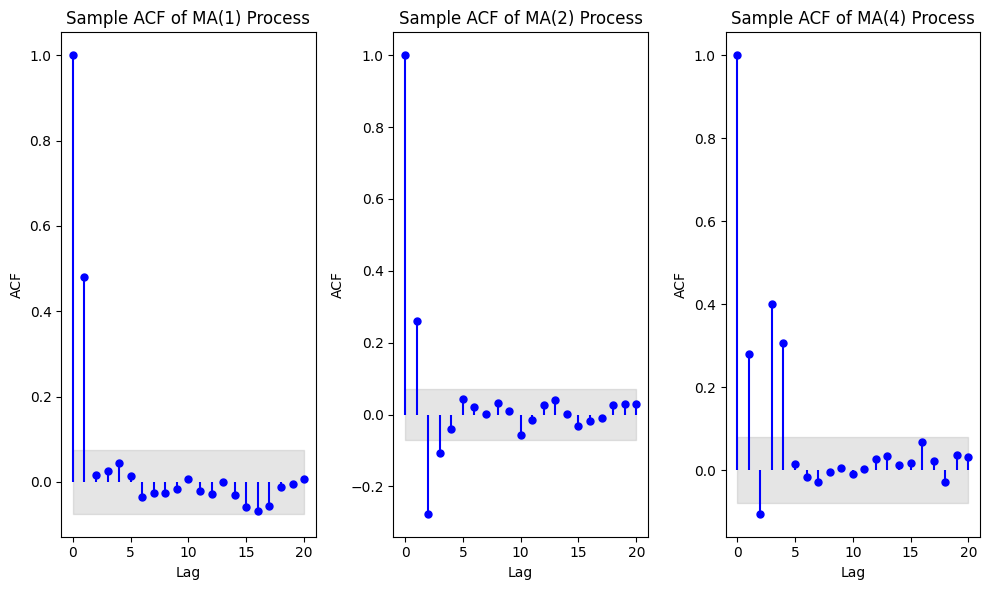

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
# Set random seed for reproducibility
np.random.seed(123)

# Parameters
T = 1000  # Sample size
lags = 20  # Number of lags for ACF

# Generate MA processes
def generate_ma(T, ma_coef):
    eps = np.random.normal(0, 1, T+len(ma_coef))  # Generate innovations
    x = np.zeros(T)
    for t in range(T):
        x[t] = eps[t]
        for j, coef in enumerate(ma_coef):
            x[t] += coef * eps[t-j-1]
    return x

# MA coefficients
ma1_coef = [0.7]  # MA(1)
ma2_coef = [0.7, -0.4]  # MA(2) 
ma4_coef = [0.7, -0.4, 0.6, 0.8]  # MA(4)

# Generate processes
ma1 = generate_ma(T, ma1_coef)
ma2 = generate_ma(T, ma2_coef)
ma4 = generate_ma(T, ma4_coef)

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))

# Plot ACF for MA(1)
acf_ma1 = acf(ma1, nlags=lags, alpha=0.05)
ax1.vlines(range(lags+1), [0], acf_ma1[0], color='blue')
ax1.plot(range(lags+1), acf_ma1[0], 'bo', markersize=5)
ax1.fill_between(range(lags+1), 
                 -1.96/np.sqrt(T) * np.sqrt(1 + 2*np.sum(acf_ma1[0][1:len(ma1_coef)+1]**2)),
                 1.96/np.sqrt(T) * np.sqrt(1 + 2*np.sum(acf_ma1[0][1:len(ma1_coef)+1]**2)),
                 alpha=0.2,
                 color='gray')
ax1.set_title('Sample ACF of MA(1) Process')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')


# Plot ACF for MA(2)
acf_ma2 = acf(ma2, nlags=lags, alpha=0.05)
ax2.vlines(range(lags+1), [0], acf_ma2[0], color='blue')
ax2.plot(range(lags+1), acf_ma2[0], 'bo', markersize=5)
ax2.fill_between(range(lags+1), 
                 -1.96/np.sqrt(T) * np.sqrt(1 + 2*np.sum(acf_ma2[0][1:len(ma2_coef)+1]**2)),
                 1.96/np.sqrt(T) * np.sqrt(1 + 2*np.sum(acf_ma2[0][1:len(ma2_coef)+1]**2)), 
                 alpha=0.2, 
                 color='gray')
ax2.set_title('Sample ACF of MA(2) Process')
ax2.set_xlabel('Lag')
ax2.set_ylabel('ACF')



# Plot ACF for MA(4)
acf_ma4 = acf(ma4, nlags=lags, alpha=0.05)
ax3.vlines(range(lags+1), [0], acf_ma4[0], color='blue')
ax3.plot(range(lags+1), acf_ma4[0], 'bo', markersize=5)
ax3.fill_between(range(lags+1), 
                 -1.96/np.sqrt(T) * np.sqrt(1 + 2*np.sum(acf_ma4[0][1:len(ma4_coef)+1]**2)),
                 1.96/np.sqrt(T) * np.sqrt(1 + 2*np.sum(acf_ma4[0][1:len(ma4_coef)+1]**2)), 
                 alpha=0.2, 
                 color='gray')
ax3.set_title('Sample ACF of MA(4) Process')
ax3.set_xlabel('Lag')
ax3.set_ylabel('ACF')


plt.tight_layout()

plt.savefig('ma_acf_plots.pdf')

plt.show()

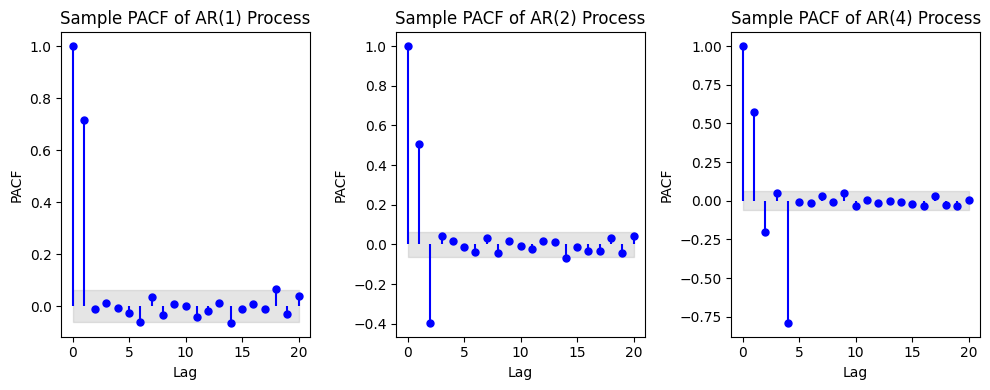

In [2]:
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima_process import arma_generate_sample

# Generate AR processes
np.random.seed(123)
T = 1000  # number of observations
lags = 20  # number of lags to plot
eps = np.random.normal(0, 1, T)

# AR(1) parameters and generation
ar1_coef = [0.7]
ar1 = np.zeros(T)
for t in range(1, T):
    ar1[t] = ar1_coef[0] * ar1[t-1] + eps[t]


# AR(2) parameters and generation  
ar2_coef = [0.7, -0.4]
ar2 = np.zeros(T)
for t in range(2, T):
    ar2[t] = ar2_coef[0] * ar2[t-1] + ar2_coef[1] * ar2[t-2] + eps[t]

# AR(4) parameters and generation
ar4_coef = [0.7, -0.4, 0.6, -0.8]
ar4 = np.zeros(T)
for t in range(4, T):
    ar4[t] = ar4_coef[0] * ar4[t-1] + ar4_coef[1] * ar4[t-2] + ar4_coef[2] * ar4[t-3] + ar4_coef[3] * ar4[t-4] + eps[t]

# Create figure for PACF plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

# Plot PACF for AR(1)
pacf_ar1 = pacf(ar1, nlags=lags, alpha=0.05)
ax1.vlines(range(lags+1), [0], pacf_ar1[0], color='blue')
ax1.plot(range(lags+1), pacf_ar1[0], 'bo', markersize=5)
ax1.fill_between(range(lags+1), -1.96/np.sqrt(T), 1.96/np.sqrt(T), 
                 alpha=0.2, color='gray')
ax1.set_title('Sample PACF of AR(1) Process')
ax1.set_xlabel('Lag')
ax1.set_ylabel('PACF')

# Plot PACF for AR(2)
pacf_ar2 = pacf(ar2, nlags=lags, alpha=0.05)
ax2.vlines(range(lags+1), [0], pacf_ar2[0], color='blue')
ax2.plot(range(lags+1), pacf_ar2[0], 'bo', markersize=5)
ax2.fill_between(range(lags+1), -1.96/np.sqrt(T), 1.96/np.sqrt(T), 
                 alpha=0.2, color='gray')
ax2.set_title('Sample PACF of AR(2) Process')
ax2.set_xlabel('Lag')
ax2.set_ylabel('PACF')

# Plot PACF for AR(4)
pacf_ar4 = pacf(ar4, nlags=lags, alpha=0.05)
ax3.vlines(range(lags+1), [0], pacf_ar4[0], color='blue')
ax3.plot(range(lags+1), pacf_ar4[0], 'bo', markersize=5)
ax3.fill_between(range(lags+1), -1.96/np.sqrt(T), 1.96/np.sqrt(T), 
                 alpha=0.2, color='gray')
ax3.set_title('Sample PACF of AR(4) Process')
ax3.set_xlabel('Lag')
ax3.set_ylabel('PACF')

plt.tight_layout()
plt.savefig('ar_pacf_plots.pdf')
plt.show()
